##  Employee Salary Prediction ML Project

In [90]:
# Import Libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [92]:
df = pd.read_csv(r"C:\Users\Sai\Downloads\Salary Data.csv")
df.head()

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0


In [93]:
df.dtypes

Age                    float64
Gender                  object
Education Level         object
Job Title               object
Years of Experience    float64
Salary                 float64
dtype: object

In [94]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 375 entries, 0 to 374
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  373 non-null    float64
 1   Gender               373 non-null    object 
 2   Education Level      373 non-null    object 
 3   Job Title            373 non-null    object 
 4   Years of Experience  373 non-null    float64
 5   Salary               373 non-null    float64
dtypes: float64(3), object(3)
memory usage: 17.7+ KB


In [96]:
print('\nMissing values:\n', df.isnull().sum())


Missing values:
 Age                    2
Gender                 2
Education Level        2
Job Title              2
Years of Experience    2
Salary                 2
dtype: int64


In [106]:
df.isnull().sum()

Age                           0
Gender                        0
Years of Experience           0
Salary                        0
Education Level_Master's      0
                             ..
Job Title_UX Designer         0
Job Title_UX Researcher       0
Job Title_VP of Finance       0
Job Title_VP of Operations    0
Job Title_Web Developer       0
Length: 179, dtype: int64

In [98]:
df.describe()

,Age,Years of Experience,Salary
count,373.000000,373.000000,373.000000
mean,37.431635,10.030831,100577.345845
std,7.069073,6.557007,48240.013482
min,23.000000,0.000000,350.000000
25%,31.000000,4.000000,55000.000000
50%,36.000000,9.000000,95000.000000
75%,44.000000,15.000000,140000.000000
max,53.000000,25.000000,250000.000000


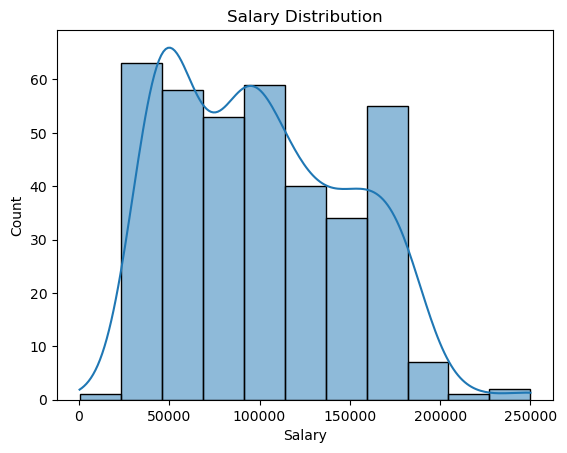

In [99]:
# Plot Salary distribution
sns.histplot(df['Salary'], kde=True)
plt.title('Salary Distribution')
plt.show()

In [101]:
# Data Preprocessing
df.dropna(inplace=True)
df['Gender'] = df['Gender'].map({'Male': 1, 'Female': 0})
df = pd.get_dummies(df, columns=['Education Level', 'Job Title'], drop_first=True)

X = df.drop('Salary', axis=1)
y = df['Salary']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [109]:
X

,Age,Gender,Years of Experience,Education Level_Master's,Education Level_PhD,Job Title_Accountant,Job Title_Administrative Assistant,Job Title_Business Analyst,Job Title_Business Development Manager,Job Title_Business Intelligence Analyst,...,Job Title_Supply Chain Manager,Job Title_Technical Recruiter,Job Title_Technical Support Specialist,Job Title_Technical Writer,Job Title_Training Specialist,Job Title_UX Designer,Job Title_UX Researcher,Job Title_VP of Finance,Job Title_VP of Operations,Job Title_Web Developer
0,32.0,1,5.0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,28.0,0,3.0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,45.0,1,15.0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,36.0,0,7.0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,52.0,1,20.0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
370,35.0,0,8.0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
371,43.0,1,19.0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
372,29.0,0,2.0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
373,34.0,1,7.0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [110]:
y

0       90000.0
1       65000.0
2      150000.0
3       60000.0
4      200000.0
         ...   
370     85000.0
371    170000.0
372     40000.0
373     90000.0
374    150000.0
Name: Salary, Length: 373, dtype: float64

In [104]:
#Train and Evaluate Models
def evaluate_model(model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print(f'{model.__class__.__name__}')
    print('R² Score:', r2_score(y_test, y_pred))
    print('RMSE:', np.sqrt(mean_squared_error(y_test, y_pred)))
    print('-' * 40)
evaluate_model(LinearRegression(), X_train, X_test, y_train, y_test)
evaluate_model(DecisionTreeRegressor(random_state=42), X_train, X_test, y_train, y_test)
evaluate_model(RandomForestRegressor(random_state=42), X_train, X_test, y_train, y_test)
evaluate_model(GradientBoostingRegressor(random_state=42), X_train, X_test, y_train, y_test)

LinearRegression
R² Score: -2.1497115721286012e+20
RMSE: 717921322168447.5
----------------------------------------
DecisionTreeRegressor
R² Score: 0.8562440680982323
RMSE: 18565.200420859095
----------------------------------------
RandomForestRegressor
R² Score: 0.8991116699044963
RMSE: 15552.751096403063
----------------------------------------
GradientBoostingRegressor
R² Score: 0.8817828281056415
RMSE: 16835.53948334601
----------------------------------------
